<a href="https://colab.research.google.com/github/AbhigyanPandey08/Groundwater-Quality-Assessment-of-Ganga-and-Varuna-River-Basins-using-Ensemble-Machine-Learning/blob/Python-notebook/SOM_GRB_VRB_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install shp
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for shp: filename=shp-2.0.0-py3-none-any.whl size=27655 sha256=46eb2642de92c71344fab0fdc5d700f999bcf0182801761e77d17ea1e95b0296
  Stored in directory: /root/.cache/pip/wheels/68/fe/d6/56a1da5a29d5ed6c5832ec3f24f03f561add8a7ea4abd40a53
Successfully built shp


Quantization Error: 1.5557
Topographic Error: 0.4314


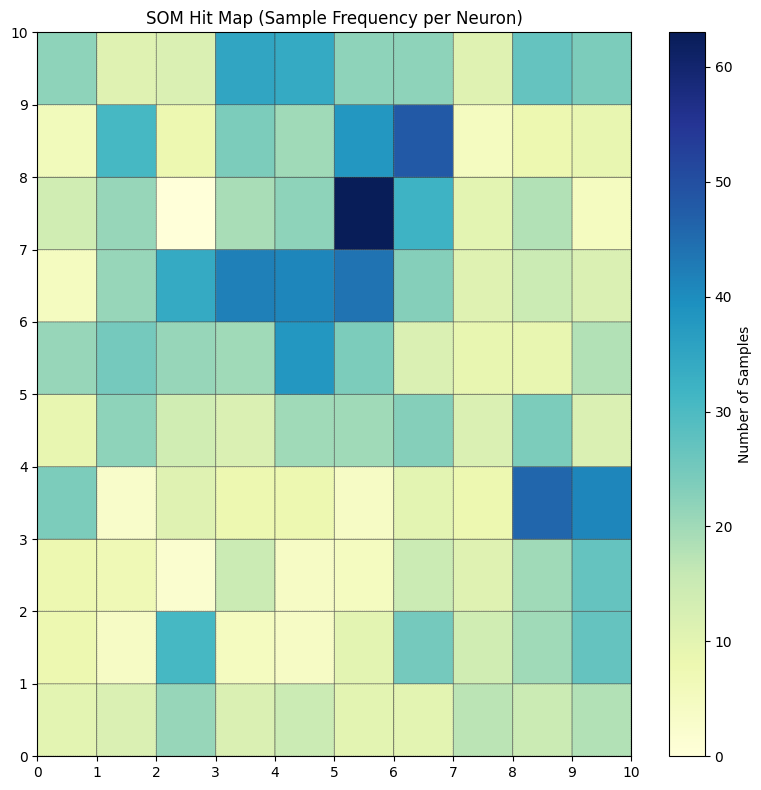

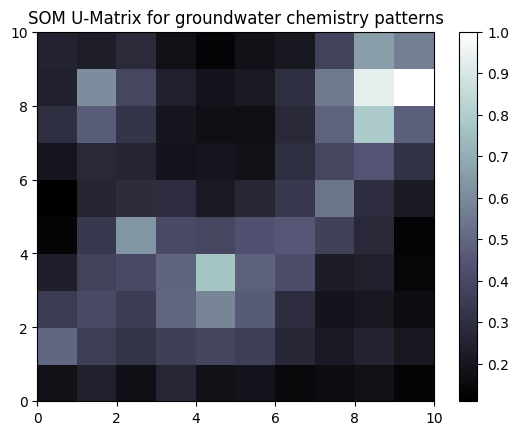


First 10 samples with SOM cluster labels:
  SOM_cluster
0         7_3
1         6_7
2         8_3
3         1_9
4         2_1
5         8_0
6         1_0
7         5_6
8         1_9
9         8_4


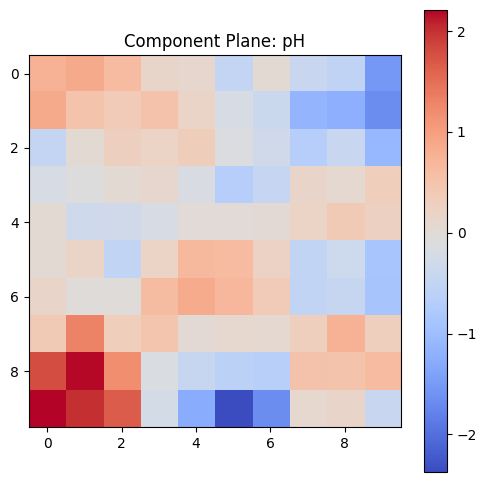

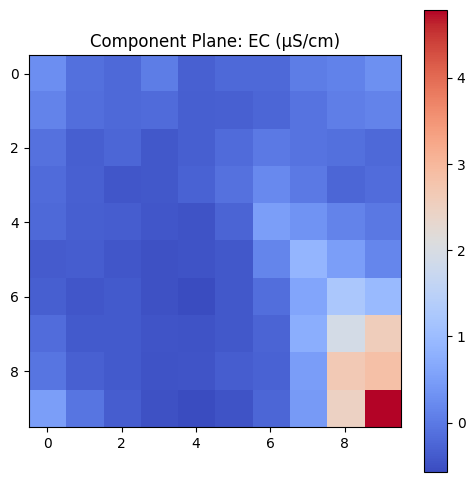

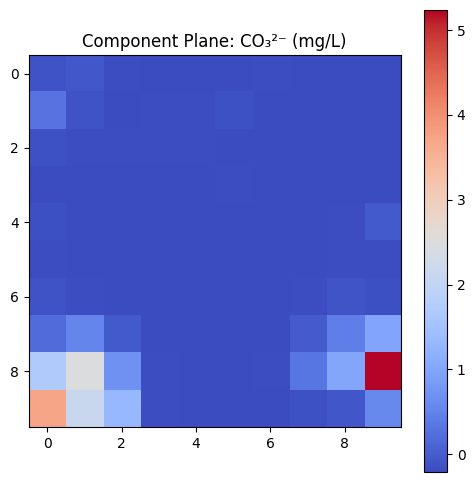

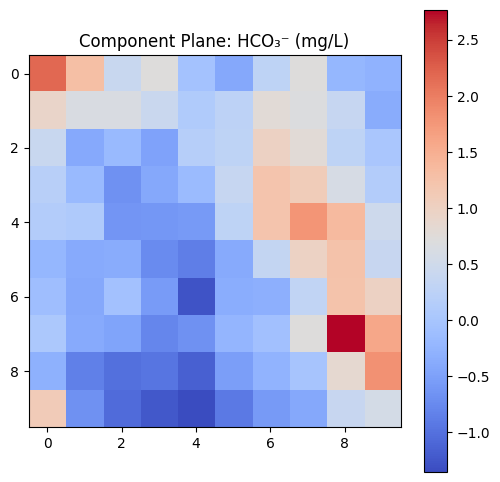

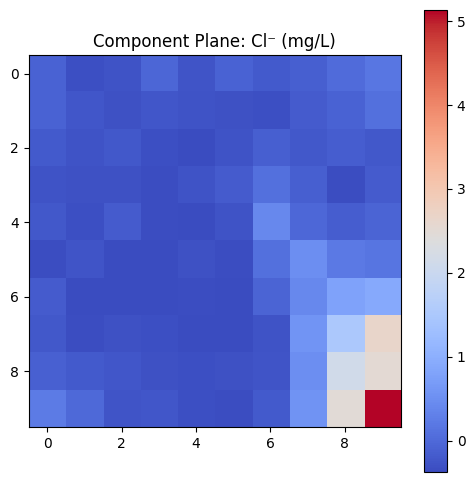

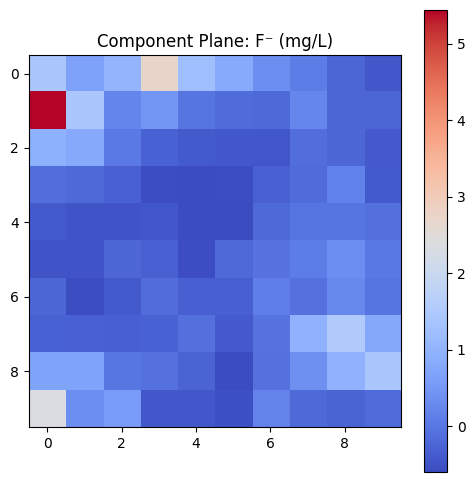

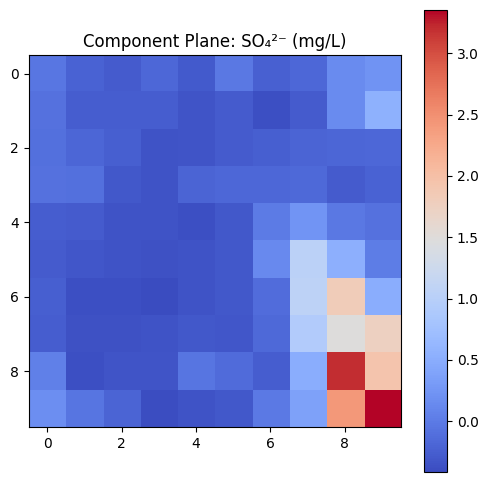

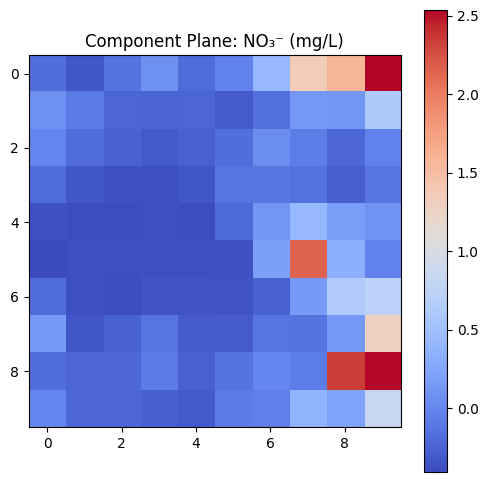

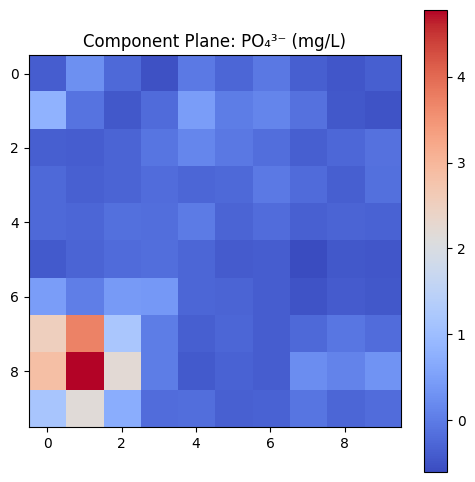

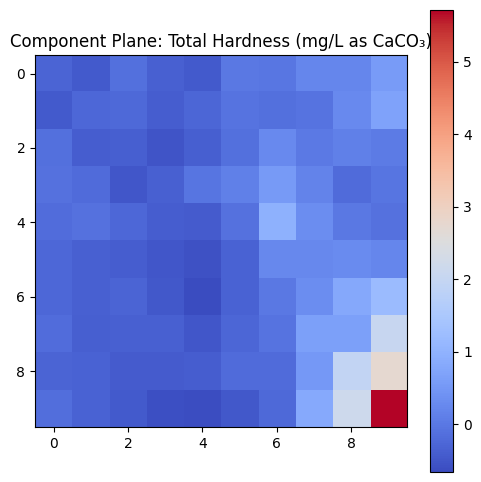

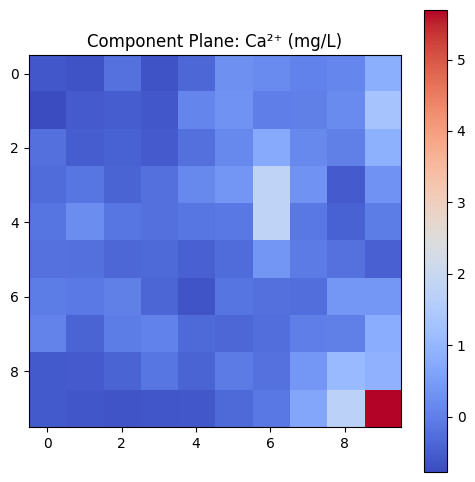

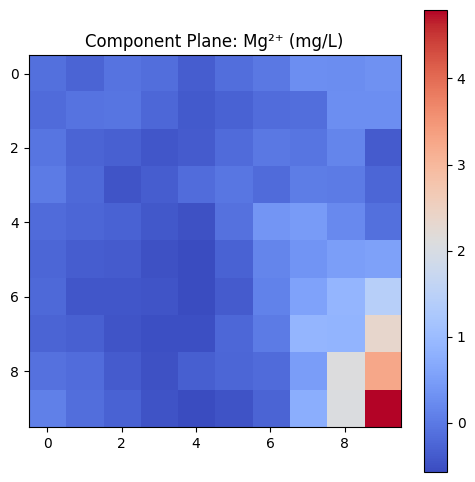

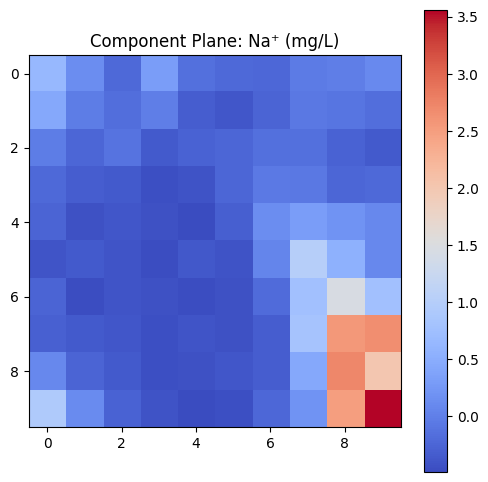

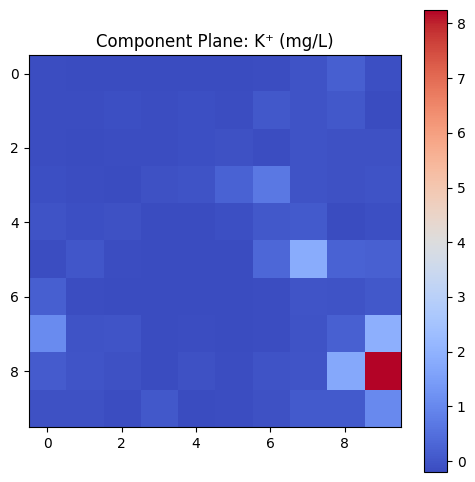

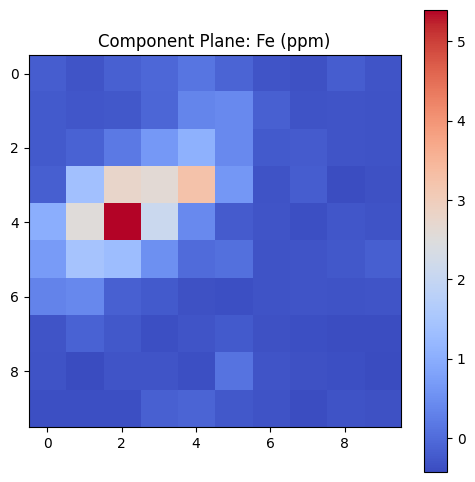

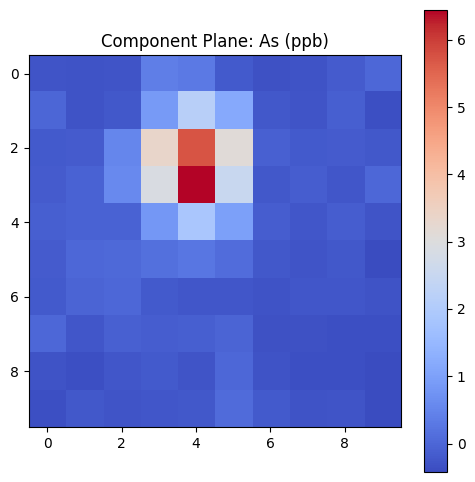

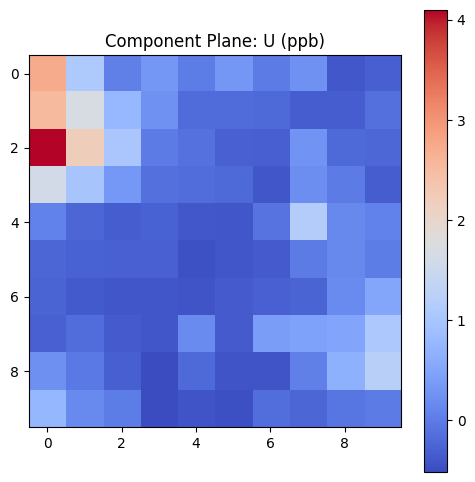

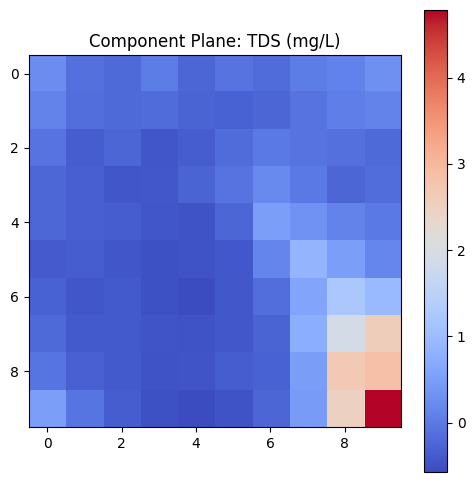

mkdir: cannot create directory ‘som_outputs’: File exists


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# SOM GRB
!pip install minisom

from minisom import MiniSom
import matplotlib.pyplot as plt
from pylab import bone, pcolor, colorbar
import shap

df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

df = df.dropna(subset=features + [target])
X = df[features]
y = df[target]

imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=features)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

som_x = 10
som_y = 10
input_len = X_scaled.shape[1]   # 18 features
som = MiniSom(som_x, som_y, input_len, sigma=1.0, learning_rate=0.5, random_seed=42)

# Training
som.train_random(X_scaled.values, 1000)  # 1000 iterations (let)
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

# Quantization & Topographic Error
q_error = som.quantization_error(X_scaled.values)
t_error = som.topographic_error(X_scaled.values)

print("Quantization Error:", round(q_error, 4))
print("Topographic Error:", round(t_error, 4))

# Build Hit Map
plt.figure(figsize=(8, 8))
plt.title("SOM Hit Map (Sample Frequency per Neuron)", fontsize=12)
frequencies = np.zeros((som_x, som_y))
for x in X_scaled.values:
    w = som.winner(x)
    frequencies[w] += 1
plt.pcolor(frequencies.T, cmap='YlGnBu', edgecolors='k', linewidths=0.2)
plt.colorbar(label="Number of Samples")
plt.xticks(np.arange(som_x + 1))
plt.yticks(np.arange(som_y + 1))
plt.grid(which='major', color='gray', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

# Plot U-matrix
bone()
pcolor(som.distance_map().T)
colorbar()
plt.title("SOM U-Matrix for groundwater chemistry patterns")
plt.show()

# Add cluster labels
bmus = np.array([som.winner(x) for x in X_scaled.values])
df['SOM_cluster'] = [f"{x[0]}_{x[1]}" for x in bmus]

print("\nFirst 10 samples with SOM cluster labels:")
print(df[['SOM_cluster']].head(10))

for i, var in enumerate(X_scaled.columns):
    plt.figure(figsize=(6,6))
    plt.title(f"Component Plane: {var}")
    plt.imshow(som.get_weights()[:,:,i].T, cmap='coolwarm')
    plt.colorbar()
    plt.show()
import shutil

!mkdir som_outputs

for i, var in enumerate(X_scaled.columns):
    plt.figure(figsize=(6,6))
    plt.title(f"Component Plane: {var}")
    plt.imshow(som.get_weights()[:,:,i].T, cmap='coolwarm')
    plt.colorbar()
    #sanitize
    safe_var = var.replace(" ", "_").replace("/","_").replace("(","").replace(")","").replace("°","").replace("%","").replace("³","3").replace("²","2")
    filename = f"som_outputs/{safe_var}_component_plane.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

# zip
shutil.make_archive("som_maps", 'zip', "som_outputs")

# download the zip
from google.colab import files
files.download("som_maps.zip")


  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=c825ef9b9f04ccc2f66e9f4d9e66748eb31ff0ef5b898ae377d240759728c44f
  Stored in directory: /root/.cache/pip/wheels/0f/8c/a4/5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built minisom
Quantization Error (VRB SOM): 0.1361
Topographic Error (VRB SOM): 0.0312


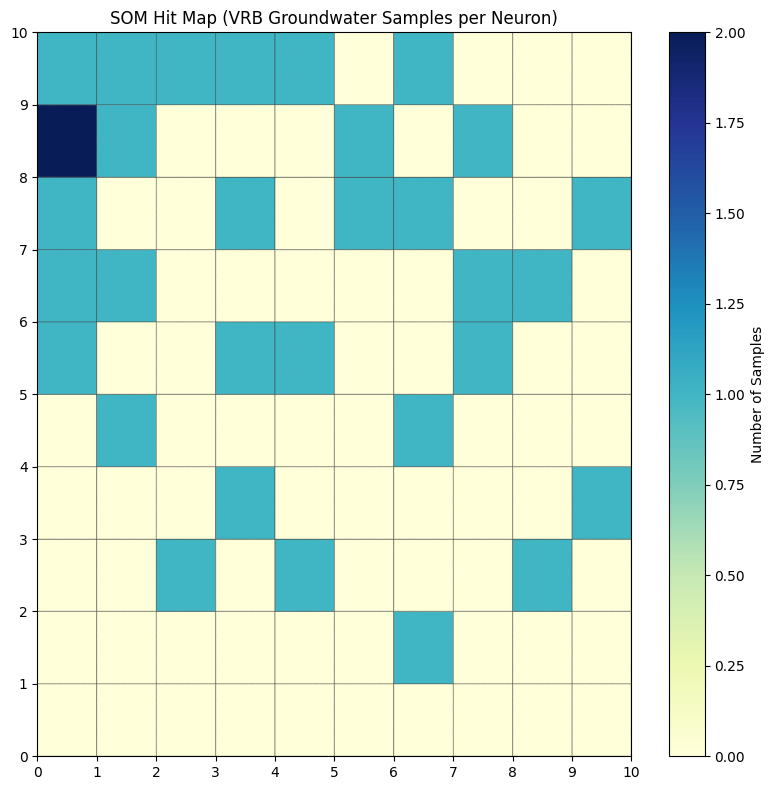

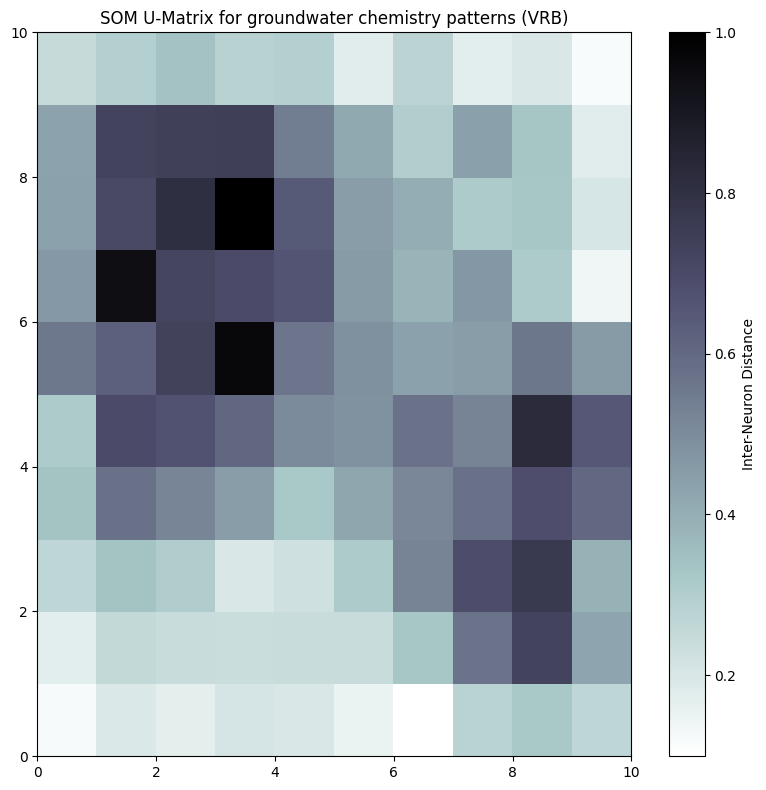

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install minisom

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import shutil

# Load VRB data (used as test set)
df = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

df = df.dropna(subset=features + [target])
X = df[features]
y = df[target]

# Impute & scale
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=features)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# SOM Initialization
som_x, som_y = 10, 10
input_len = X_scaled.shape[1]
som = MiniSom(som_x, som_y, input_len, sigma=1.0, learning_rate=0.5, random_seed=42)

# Train SOM on VRB (assuming retraining for VRB; otherwise use pretrained weights from GRB)
som.train_random(X_scaled.values, 1000)

# SOM Errors
q_error = som.quantization_error(X_scaled.values)
t_error = som.topographic_error(X_scaled.values)
print("Quantization Error (VRB SOM):", round(q_error, 4))
print("Topographic Error (VRB SOM):", round(t_error, 4))

# Hit Map
plt.figure(figsize=(8, 8))
plt.title("SOM Hit Map (VRB Groundwater Samples per Neuron)", fontsize=12)
frequencies = np.zeros((som_x, som_y))
for x in X_scaled.values:
    w = som.winner(x)
    frequencies[w] += 1
plt.pcolor(frequencies.T, cmap='YlGnBu', edgecolors='k', linewidths=0.2)
plt.colorbar(label="Number of Samples")
plt.xticks(np.arange(som_x + 1))
plt.yticks(np.arange(som_y + 1))
plt.grid(which='major', color='gray', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

# U-Matrix
plt.figure(figsize=(8, 8))
plt.title("SOM U-Matrix for groundwater chemistry patterns (VRB)")
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label="Inter-Neuron Distance")
plt.tight_layout()
plt.show()

# Component Planes (Kohonen Feature Maps)
!mkdir -p som_outputs
for i, var in enumerate(X_scaled.columns):
    plt.figure(figsize=(6, 6))
    plt.title(f"Component Plane: {var}")
    plt.imshow(som.get_weights()[:, :, i].T, cmap='coolwarm')
    plt.colorbar()
    safe_var = var.replace(" ", "_").replace("/","_").replace("(","").replace(")","").replace("°","").replace("%","").replace("³","3").replace("²","2")
    filename = f"som_outputs/{safe_var}_component_plane.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

# Export ZIP of Component Planes
shutil.make_archive("som_mapsVRB", 'zip', "som_outputs")
from google.colab import files
files.download("som_mapsVRB.zip")

In [ ]:
#PPI Calculation
import pandas as pd
import numpy as np

df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")

# SHAP-derived feature weights
shap_weights = {
    "Fe (ppm)": 0.158, "EC (µS/cm)": 0.094, "NO₃⁻ (mg/L)": 0.088,
    "Cl⁻ (mg/L)": 0.080, "TDS (mg/L)": 0.073, "Mg²⁺ (mg/L)": 0.061,
    "K⁺ (mg/L)": 0.059, "As (ppb)": 0.058, "Ca²⁺ (mg/L)": 0.045,
    "Na⁺ (mg/L)": 0.044, "SO₄²⁻ (mg/L)": 0.036, "F⁻ (mg/L)": 0.034,
    "U (ppb)": 0.033, "Total Hardness (mg/L as CaCO₃)": 0.031,
    "CO₃²⁻ (mg/L)": 0.023, "HCO₃⁻ (mg/L)": 0.014,
    "pH": 0.013, "PO₄³⁻ (mg/L)": 0.016
}

# WHO/BIS regulatory limits
limits = {
    "Fe (ppm)": 1.0, "EC (µS/cm)": 2000, "NO₃⁻ (mg/L)": 45,
    "Cl⁻ (mg/L)": 250, "TDS (mg/L)": 2000, "Mg²⁺ (mg/L)": 100,
    "K⁺ (mg/L)": 12, "As (ppb)": 10, "Ca²⁺ (mg/L)": 75,
    "Na⁺ (mg/L)": 200, "SO₄²⁻ (mg/L)": 250, "F⁻ (mg/L)": 1.5,
    "U (ppb)": 30, "Total Hardness (mg/L as CaCO₃)": 300,
    "CO₃²⁻ (mg/L)": 30, "HCO₃⁻ (mg/L)": 500,
    "pH": (6.5, 8.5), "PO₄³⁻ (mg/L)": 0.5
}

# Sigmoid parameters
k = 3      # steepness of the curve
x0 = 1.0   # midpoint (typically RQ = 1)

# Compute log+sigmoid-weighted raw PPI
ppi_raw = []
for _, row in df.iterrows():
    score = 0
    for param, weight in shap_weights.items():
        if param == "pH":
            low, high = limits["pH"]
            deviation = max(low - row[param], row[param] - high, 0)
            rq = deviation / max(abs(low - 7.5), abs(high - 7.5))
        else:
            rq = row[param] / limits[param]

        log_rq = np.log1p(rq)
        sigmoid_log = 1 / (1 + np.exp(-k * (log_rq - x0)))
        score += weight * sigmoid_log
    ppi_raw.append(score)

df["PPI_LogSigmoid_raw"] = ppi_raw

# Define fixed theoretical max (all pollutants at 3× limit)
PPI_theoretical_max = sum([
    w * (1 / (1 + np.exp(-k * (np.log1p(3) - x0))))
    for w in shap_weights.values()
])

# Scale PPI and compute delta
df["PPI_LogSigmoid_scaled"] = 100 * df["PPI_LogSigmoid_raw"] / PPI_theoretical_max
df["Delta (GWQI - PPI_LogSigmoid_scaled)"] = df["GWQI (0–100 Index)"] - df["PPI_LogSigmoid_scaled"]

# Save final result
df.to_csv("Varuna_River_Basin_PPI_LogSigmoid_TheoreticalMax.csv", index=False)


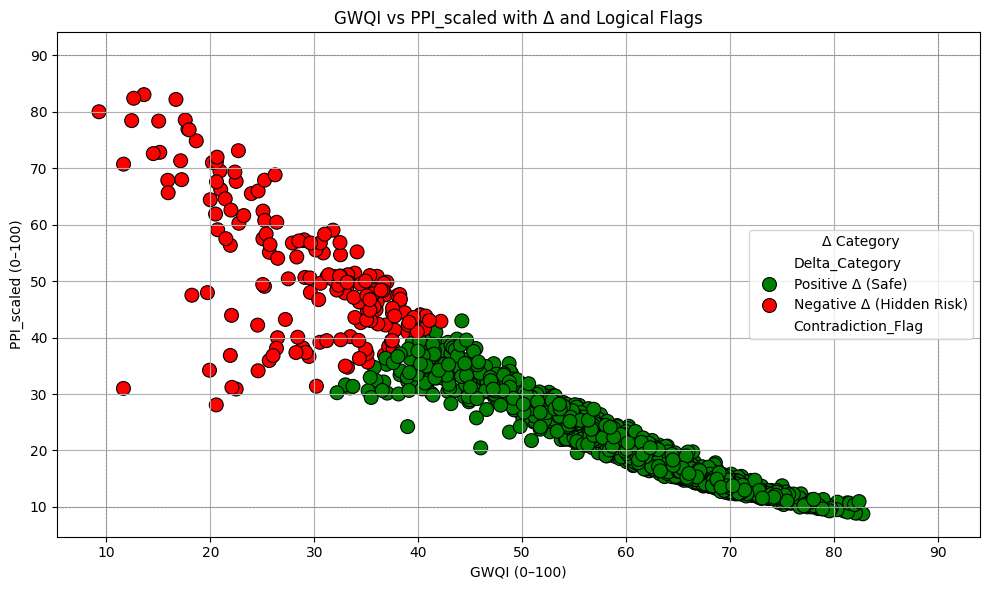

In [ ]:
#GWQI and PPI scatter plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Ganga_River_Basin_PPI.csv")

# Rename for simplicity (optional but helpful)
df["GWQI"] = df["GWQI (0–100 Index)"]
df["PPI_scaled"] = df["PPI_LogSigmoid_scaled"]
df["Delta"] = df["Delta (GWQI - PPI_LogSigmoid_scaled)"]

# Categorize delta
df["Delta_Category"] = df["Delta"].apply(lambda x: "Positive Δ (Safe)" if x > 0 else "Negative Δ (Hidden Risk)")

# Contradiction / Pristine flag
def contradiction_flag(row):
    if row["GWQI"] > 90 and row["PPI_scaled"] > 90:
        return "Contradiction"
    elif row["GWQI"] > 90 and row["PPI_scaled"] < 10:
        return "Pristine"
    else:
        return ""

df["Contradiction_Flag"] = df.apply(contradiction_flag, axis=1)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="GWQI",
    y="PPI_scaled",
    hue="Delta_Category",
    style="Contradiction_Flag",
    palette={"Positive Δ (Safe)": "green", "Negative Δ (Hidden Risk)": "red"},
    s=100,
    edgecolor="black"
)

# Add reference lines
plt.axhline(90, color='grey', linestyle='--', linewidth=0.5)
plt.axhline(10, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(90, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(10, color='grey', linestyle='--', linewidth=0.5)

# Add titles and labels
plt.title("GWQI vs PPI_scaled with Δ and Logical Flags")
plt.xlabel("GWQI (0–100)")
plt.ylabel("PPI_scaled (0–100)")
plt.legend(title="Δ Category")
plt.grid(True)
plt.tight_layout()
plt.show()


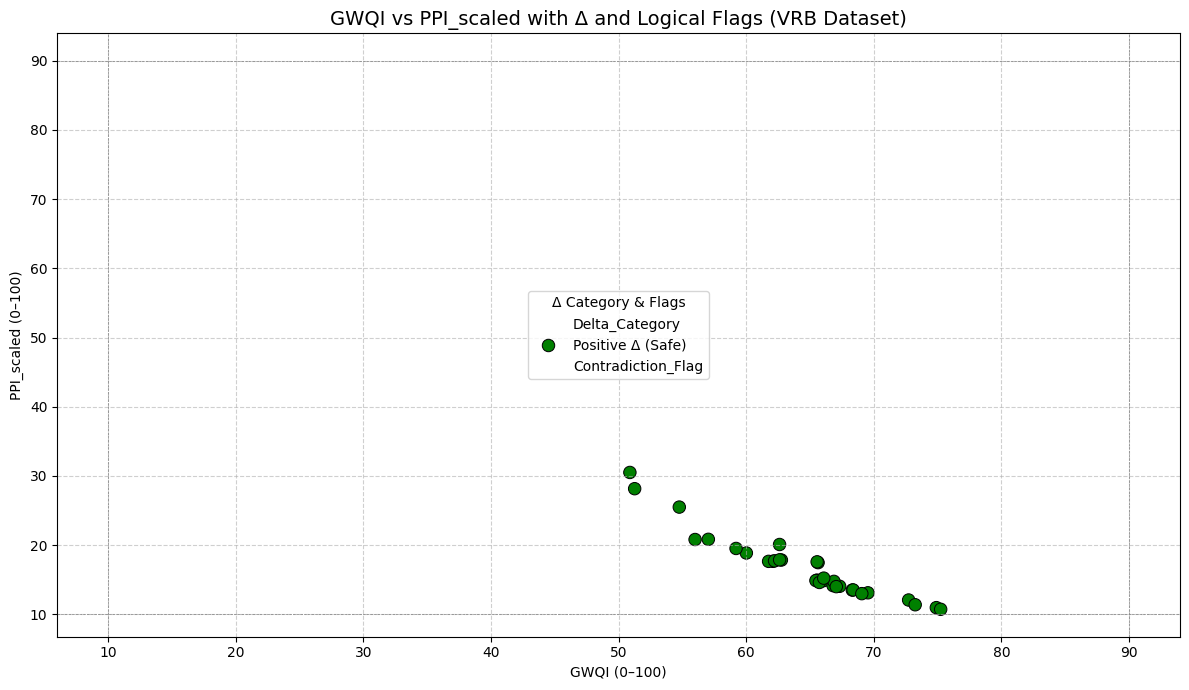

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Varuna_River_Basin_PPI.csv")

# Rename columns for simplicity
df = df.rename(columns={
    "GWQI (0–100 Index)": "GWQI",
    "PPI_LogSigmoid_scaled": "PPI_scaled",
    "Delta (GWQI - PPI_scaled)": "Delta"
})

# Categorize delta
df["Delta_Category"] = df["Delta"].apply(lambda x: "Positive Δ (Safe)" if x > 0 else "Negative Δ (Hidden Risk)")

# Contradiction / Pristine flag
def contradiction_flag(row):
    if row["GWQI"] > 90 and row["PPI_scaled"] > 90:
        return "Contradiction"
    elif row["GWQI"] > 90 and row["PPI_scaled"] < 10:
        return "Pristine"
    else:
        return ""

df["Contradiction_Flag"] = df.apply(contradiction_flag, axis=1)

# Scatter plot with fixed dot markers
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="GWQI",
    y="PPI_scaled",
    hue="Delta_Category",
    style="Contradiction_Flag",
    palette={"Positive Δ (Safe)": "green", "Negative Δ (Hidden Risk)": "red"},
    markers={"": "o", "Contradiction": "X", "Pristine": "P"},  # circles for normal, X for contradiction, P for pristine
    s=80,
    edgecolor="black"
)

# Reference lines
plt.axhline(90, color='grey', linestyle='--', linewidth=0.5)
plt.axhline(10, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(90, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(10, color='grey', linestyle='--', linewidth=0.5)

# Labels and title
plt.title("GWQI vs PPI_scaled with Δ and Logical Flags (VRB Dataset)", fontsize=14)
plt.xlabel("GWQI (0–100)")
plt.ylabel("PPI_scaled (0–100)")
plt.legend(title="Δ Category & Flags", loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


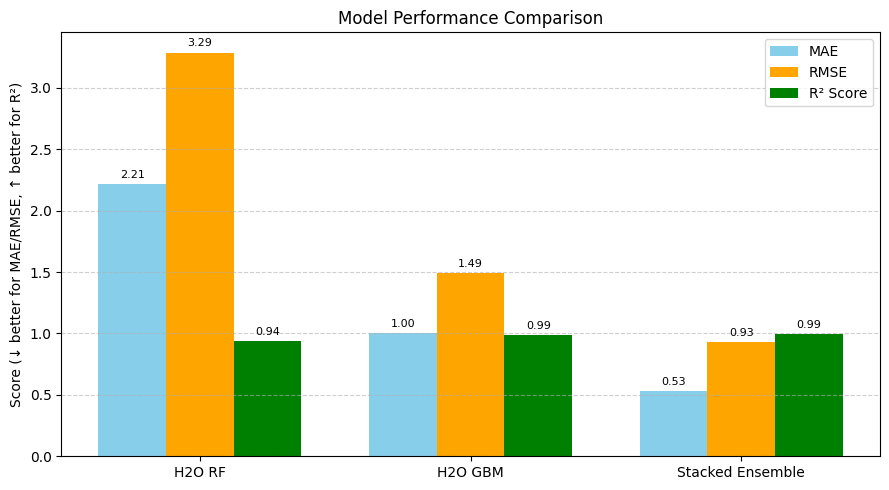

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["H2O RF", "H2O GBM", "Stacked Ensemble"]
mae = [2.2142, 1.0043, 0.533]
rmse = [3.2866, 1.4889, 0.929]
r2 = [0.9404, 0.9878, 0.995]

x = np.arange(len(models))
width = 0.25

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width, mae, width, label='MAE', color='skyblue')
bars2 = ax.bar(x, rmse, width, label='RMSE', color='orange')
bars3 = ax.bar(x + width, r2, width, label='R² Score', color='green')

# Y-axis label
ax.set_ylabel('Score (↓ better for MAE/RMSE, ↑ better for R²)')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Value annotations
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Offset text above bar
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

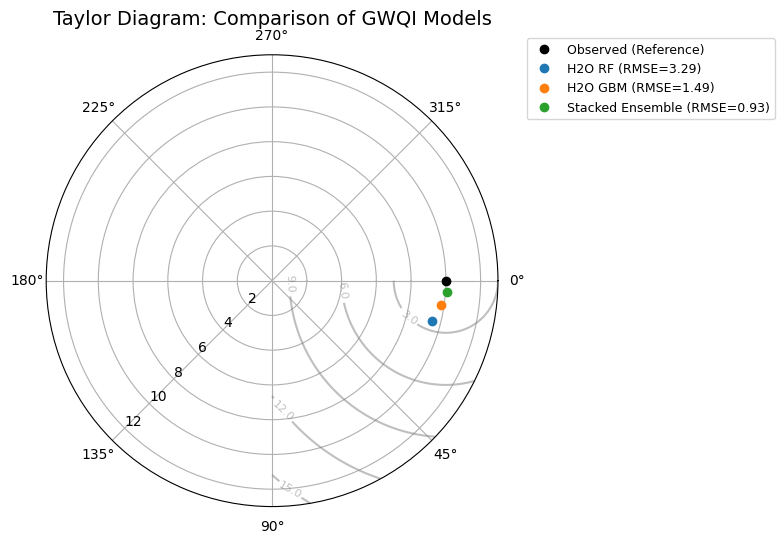

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Model Metrics
models = ["H2O RF", "H2O GBM", "Stacked Ensemble"]
std_devs = [9.5, 9.8, 10.1]        # Replace with actual std devs of model predictions
correlations = [0.97, 0.99, 0.998] # Correlation coefficients with observed
rmse = [3.29, 1.49, 0.93]          # RMSE values

# Observed Reference
sigma_ref = 10.0  # Std dev of observed GWQI (can be updated if known)

# Polar Coordinates
angles = np.arccos(correlations)  # Convert correlation to angle (radians)

# Create Polar Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)

# Plot Observed Point
ax.plot([0], [sigma_ref], 'ko', label="Observed (Reference)")

# Plot Models
for i, model in enumerate(models):
    ax.plot(angles[i], std_devs[i], 'o', label=f"{model} (RMSE={rmse[i]:.2f})")

# CRMSE Contours
rs, ts = np.meshgrid(np.linspace(0, sigma_ref * 1.3, 100), np.linspace(0, np.pi/2, 100))
crmse = np.sqrt(sigma_ref**2 + rs**2 - 2*sigma_ref*rs*np.cos(ts))
contours = ax.contour(ts, rs, crmse, levels=5, colors='gray', alpha=0.5)
ax.clabel(contours, inline=1, fontsize=8, fmt="%.1f")

# Aesthetics
ax.set_rmax(sigma_ref * 1.3)
ax.set_rlabel_position(135)
ax.set_title("Taylor Diagram: Comparison of GWQI Models\n", fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.05), fontsize=9)
# Improve layout
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


<Figure size 1400x1200 with 0 Axes>

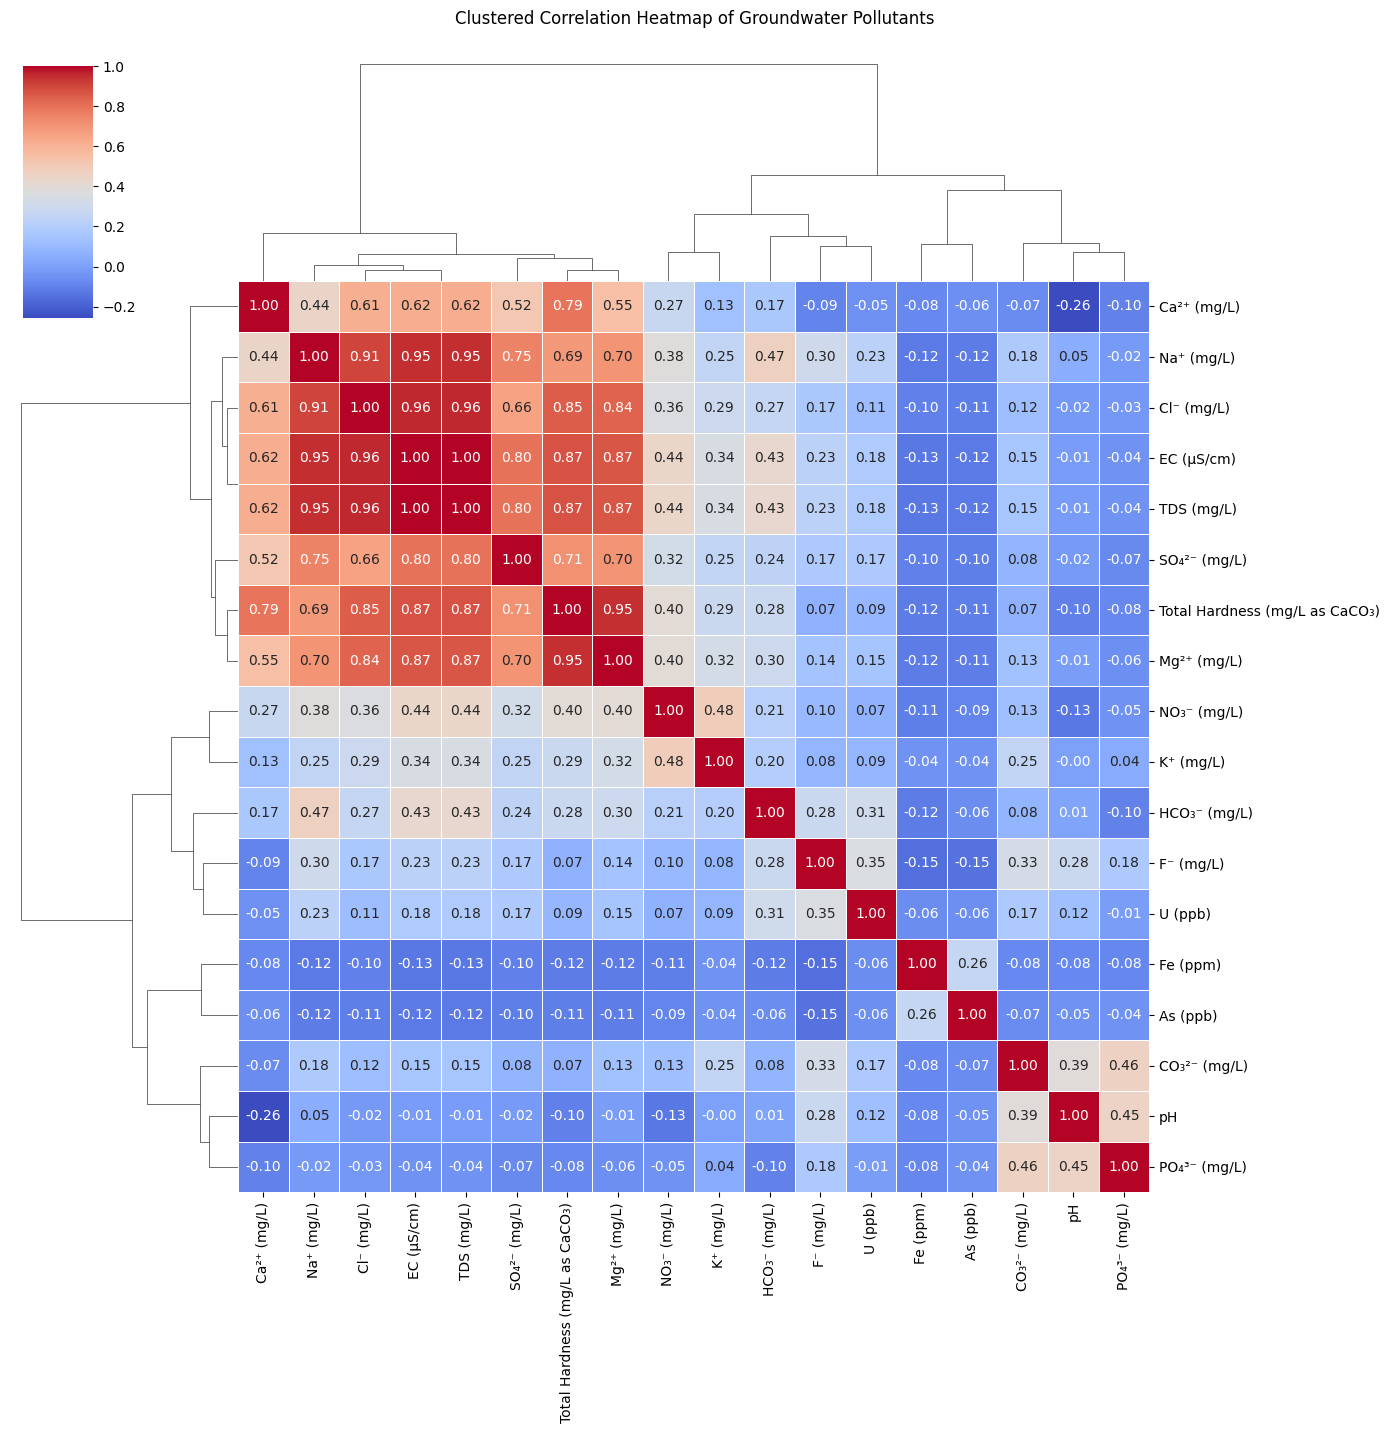

In [ ]:
import pandas as pd
df = pd.read_csv("Ganga_River_Basin_PPI.csv")
pollutants = [
    "pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
    "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
    "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)",
    "As (ppb)", "U (ppb)", "TDS (mg/L)"
]

corr_matrix = df[pollutants].corr(method="pearson")
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
# Dendrogram-enhanced clustermap
sns.clustermap(
    corr_matrix,
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    figsize=(14, 14)
)
plt.suptitle("Clustered Correlation Heatmap of Groundwater Pollutants", y=1.02)
plt.show()
